# Instrument definition

In [18]:
import mcstasscript as ms

ess_w7 = ms.McStas_instr(
    "ESS_butterfly_W7",
    author="Bing Li",
    origin="DMSC",
    input_path="./ESS_butterfly_W7",
    output_path="./ESS_butterfly_W7/out",
)


bender = ess_w7.add_parameter(
    "int", "bender", value=1, comment="bender out = 0, bender in = 1"
)
b_rot = ess_w7.add_parameter(
    "double",
    "b_rot",
    value=-0.397881,
    comment="in [deg], rotation of the cold neutron bender = -atan(0.05/7.2), full deflection since endFlat=0",
)

# Declare section

In [19]:
frac = ess_w7.add_declare_var(
    "double",
    "frac",
    value=0.3,
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)

# Initialize section

In [20]:
ess_w7.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value  
------------------------------------------
double  frac                         0.3    



# Trace section
Source

In [21]:
source = ess_w7.add_component(name="source", component_name="ESS_butterfly")
source.set_parameters(
    sector='"W"',
    beamline=7,
    Lmin=0.1,  # in Angstrom
    Lmax=10.0,  # in Angstrom
    acc_power=2,  # [MW]
    yheight=0.03,  # [m], moderator height, 0.03 to 0.06
    cold_frac=frac,
    # target_index not needed if using dist
    dist=2,  # [m], distance to focusing rectange
    focus_xw=0.095,  # [m], size of focusing rectange
    focus_yh=0.035,
    # c_performance: float = 1.0
    # t_performance: float = 1.0
    n_pulses=1,
    # tfocus_dist="position_BW2[2]",  # [m], Position of time focusing window along z axis
    # tfocus_time="tof_BW2",  # [s], position of time focusing window
    # tfocus_width=0.02,  # [s], width of time focusing window
)  # ess_w7.component_help("ESS_butterfly")

NBOA (Neutron Beam Optics Assembly), guide_1 -> guide_4a/4b

/* ============================================================================

NBOA - ASYMMETRIC TAPER

The -x wall of the NBOA is FIXED at -47.000 mm; all of the horizontal
narrowing (90 -> 60 mm) is taken out of the +x wall, which is the cold
moderator side. This is the bispectral extraction geometry: the view of the
thermal face is held constant while the cold-side acceptance is trimmed.

Consequence: the guide centre-line is NOT the nominal beam axis. It is a
straight line from -2.0295 mm at 1895.927 mm to -16.8711 mm at 5881.65 mm,
tilted by -0.213350 deg = half the 0.426695 deg ToO horizontal taper angle.

Guide_gravity is symmetric about its own axis, but two straight walls are
reproduced EXACTLY by a symmetric guide placed on their bisector. The tilt is
identical for all four sections, so one arm carries the whole NBOA and the
sections hang off it with plain z offsets.

The -x wall releases at 5.927 m; from Guide_5 onward the guide is symmetric
about its own axis again, so the tilt is removed there.

============================================================================= */

In [22]:
import numpy as np
from mctrex.params_guide import guide_1, guide_4b

taper_angle = np.degrees(
    np.arctan((guide_1.w1 - guide_4b.w2) / (guide_4b.z2 - guide_1.z1) / 2)
)
fixed_wall_at = -0.047  # m
position = [
    (guide_1.w1 * np.cos(np.radians(taper_angle)) / 2 + fixed_wall_at),
    0,
    guide_1.z1,
]
arm_NBOA = ess_w7.add_component(
    name="arm_NBOA", component_name="Arm", AT=position, ROTATED=[0, -taper_angle, 0]
)

In [23]:
from mctrex.params_guide import guide_1, guide_2, guide_3, guide_4a, guide_4b, guide_5

guide_1.AT = [0, 0, 0]
guide_1.RELATIVE=arm_NBOA
guide_1.add_to(ess_w7)

COMPONENT Guide_1 = Guide_gravity(
  w1 = 0.089955, // [m]
  h1 = 0.029992, // [m]
  w2 = 0.082455, // [m]
  h2 = 0.034937, // [m]
  l = 0.9994, // [m]
  mleft = 1.5, // [1]
  mright = 1.5, // [1]
  mtop = 4, // [1]
  mbottom = 4 // [1]
)
AT (0, 0, 0) RELATIVE arm_NBOA
ROTATED (0, 0, 0) RELATIVE arm_NBOA

In [24]:
guide_2.AT = [0, 0, guide_2.z1-guide_1.z1]
guide_2.RELATIVE=arm_NBOA
component_guide_2 = guide_2.add_to(ess_w7)
component_guide_2.set_comment("1.0 mm gap after Guide_1")

In [25]:
guide_3.AT = [0, 0, guide_3.z1-guide_1.z1]
guide_3.RELATIVE=arm_NBOA
component_guide_3 = guide_3.add_to(ess_w7)
component_guide_3.set_comment("1.2 mm gap after Guide_2")

 BBGOA (Beam Bridge Guide Optics Assembly)

/* =============================================================================

BBGOA SECTION 4 - EXCHANGE ASSEMBLY  (4a thermal  <->  4b cold + bender)

4a and 4b occupy the same slot in the BBGOA and share the same exit plane at
5881.65 mm; they are alternative optics that swap in and out, NOT parallel
beamlines. Both are anchored to Guide_3 so the two WHEN branches are fully
independent of each other.

Ref: ToO v3.2

============================================================================= */

/* ---- 4a: thermal guide  |  5400.65 -> 5881.65 mm  |  481 mm  |  Aluminium --- */

In [26]:
guide_4a.AT = [0, 0, guide_4a.z1-guide_1.z1]
guide_4a.RELATIVE=arm_NBOA
component_guide_4a = guide_4a.add_to(ess_w7)
component_guide_4a.set_WHEN("bender==0")

/* ---- 4b: bender + cold guide |  5400 -> 5450.65 -> 5881.65 mm  |  50 + 431 mm  |  Aluminium

The bender is a 50 mm solid-state Si stack at the UPSTREAM end of 4b
(5400.65 -> 5450.65 mm), followed by 381 mm of tapered cold guide (5450.65 -> 5881.65 mm).
Every Si channel is 0.15 mm wide, sputtered on every side with Ni/Ti m=4,
blade radius of curvature 7.2 m -> deflection = atan(0.05/7.2) = 0.3979 deg.
The entrance is oriented toward the cold moderator; the exit tangent lies on
the nominal guide axis, so nothing downstream of 4b is rotated.

NOTE: radius > 0 curves left (+x). */

In [27]:
bender = ess_w7.add_component(
    name="bender",
    component_name="Pol_bender",
    AT=guide_4a.AT,
    ROTATED=[0, b_rot, 0],
    RELATIVE=arm_NBOA,
    WHEN="bender==1",
)
bender.set_parameters(
    xwidth=0.063466,
    yheight=0.044759,
    length=0.050,
    radius=7.2,
    nslit=426,
    d=1e-6,
    endFlat=0,
    drawOption=2,
    # match G=0 used by every Guide_gravity;
    # comp default is 9.8 and its gravity path
    # is flagged untested in the component BUGS
    # G=0,
    # All four walls set explicitly: the component description says Bot/Left/
    # Right inherit from Top, but the parameter table lists an independent
    # m=2 default for each. Explicit values settle the ambiguity.
    # Identical Up/Down arrays make the component spin-independent.
    rTopUpPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rTopDownPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rBotUpPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rBotDownPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rLeftUpPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rLeftDownPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rRightUpPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rRightDownPar={0.99, 0.0219, 3.02, 4.0, 0.003},
)
bender.set_comment("5400.65 mm -> 5450.65 mm, the try10 slot")

In [28]:
guide_4b.AT = [0, 0, guide_4b.z1-guide_1.z1]
guide_4b.RELATIVE=arm_NBOA
component_guide_4b = guide_4b.add_to(ess_w7)
component_guide_4b.set_WHEN("bender==1")
component_guide_4b.set_comment("5450.65 -> 5881.65 mm, 431 mm - the full section */")

In [29]:
ess_w7.backengine()


INFO: Using directory: "/Users/bingli/Documents/GitHub/mctrex/src/mctrex/ESS_butterfly_W7/out_11"
INFO: Regenerating c-file: ESS_butterfly_W7.c
CFLAGS=
            
 The parameter rTopUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rTopDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal number

[]

In [30]:
# ess_w7.show_instrument()
# ess_w7.show_instrument(backend="pythreejs")

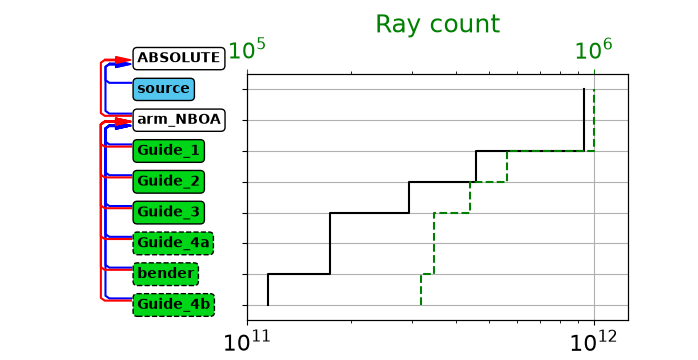

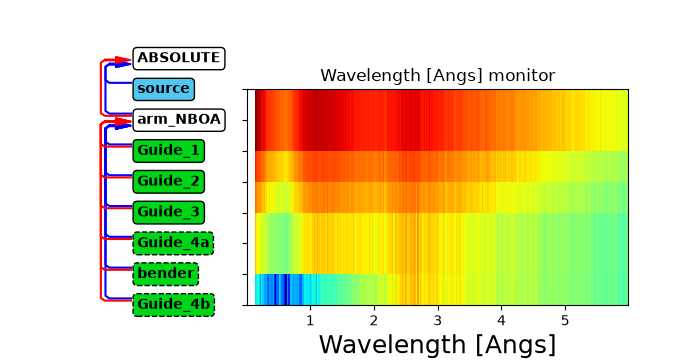

In [31]:
ess_w7.set_parameters(bender=1)
ess_w7.show_diagram(analysis=True)
ess_w7.show_diagram(variable="l", limits=[0, 6])

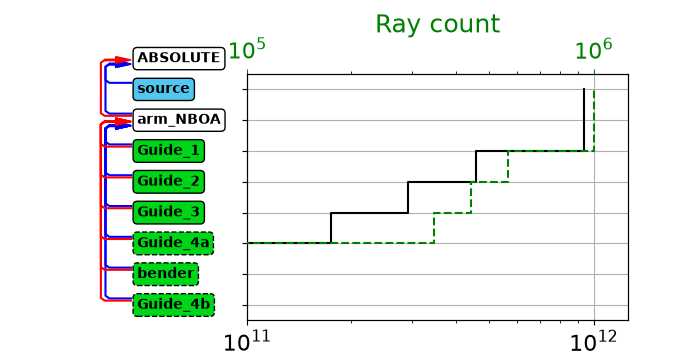

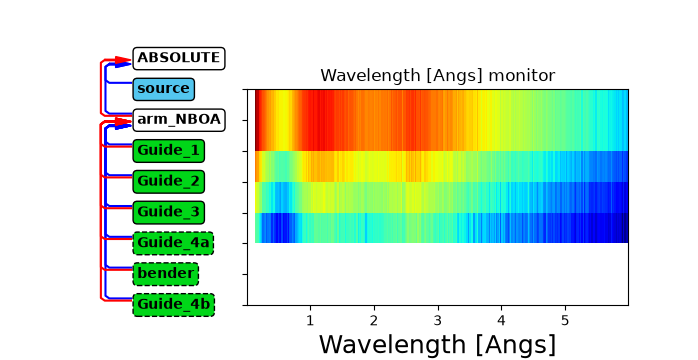

In [32]:
ess_w7.set_parameters(bender=0)
ess_w7.show_diagram(analysis=True)
ess_w7.show_diagram(variable="l", limits=[0, 6])

# Diagnostics

In [33]:
diag = ms.Diagnostics(ess_w7)

diag.settings(ncount=1e7, suppress_output=True, mpi="auto")
diag.show_settings()

Instrument settings:
  ncount:           1.00e+07
  mpi:              auto 
  output_path:      ESS_butterfly_W7/out
  run_path:         ./ESS_butterfly_W7
  package_path:     /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/share/mcstas/resources
  executable_path:  /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/bin
  executable:       mcrun
  force_compile:    True
  NeXus:            False
  save_comp_pars:   False


In [34]:
diag.clear_points()
diag.add_point(after="source")
diag.add_point(before="Guide_1")
diag.add_point(after="Guide_3")
diag.add_point(after="Guide_4a")

In [35]:
diag.set_parameters(bender=1)
diag.show_parameters()

int    bender  = 1          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [36]:
diag.run()

In [37]:
diag.clear_views()
diag.add_view("x", "y", bins=100)
# diag.add_view("vx", "vy", bins=200)
# diag.add_view("dx", "dy", bins=100)
# diag.add_view("l", bins=100)
# diag.add_view("t", bins=100)
diag.add_view("x", "l", bins=100)
diag.add_view("t", "l", bins=100)

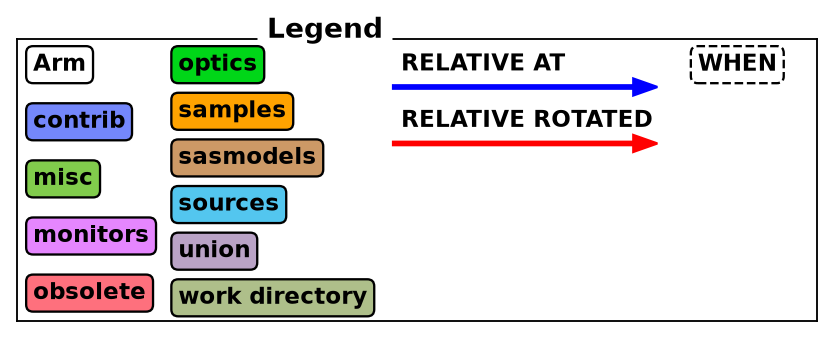

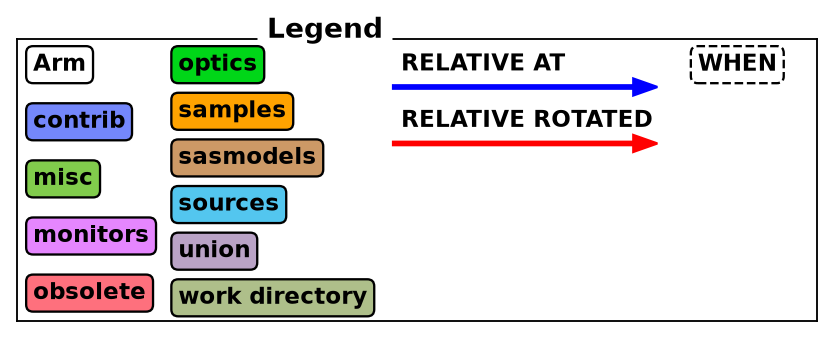

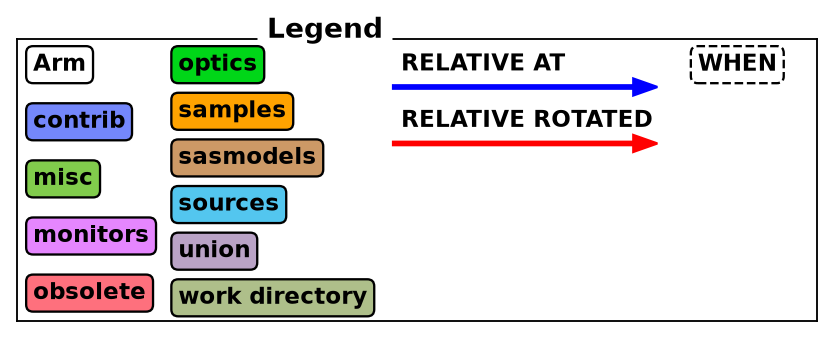

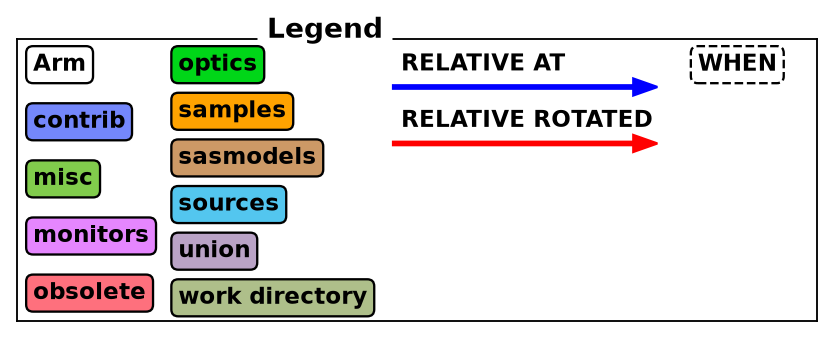

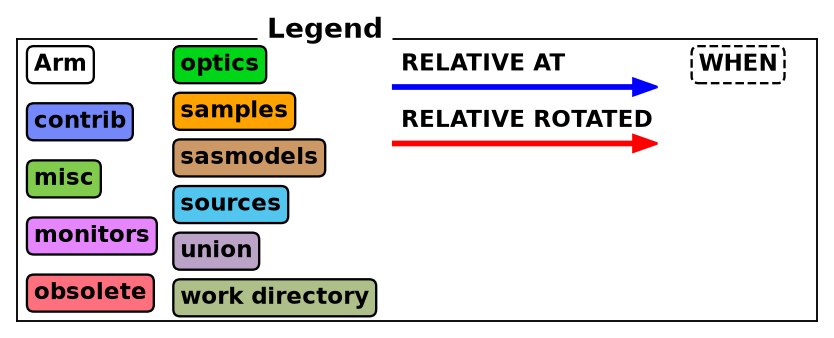

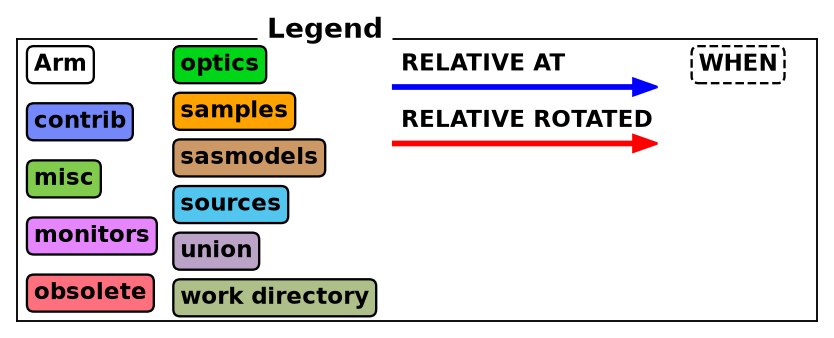

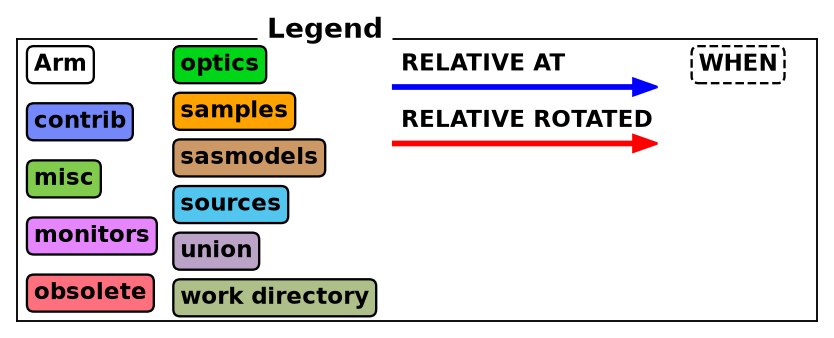

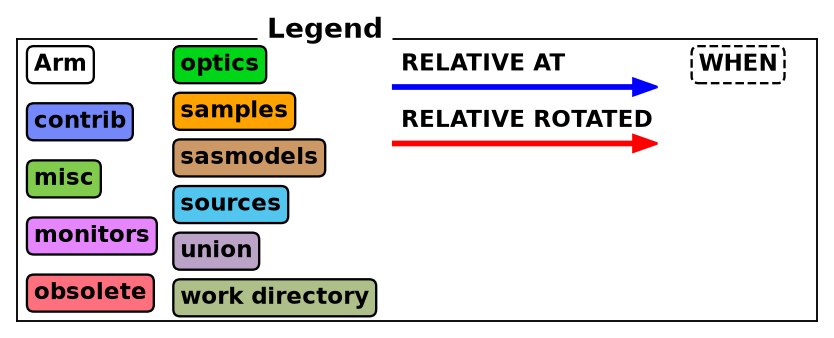

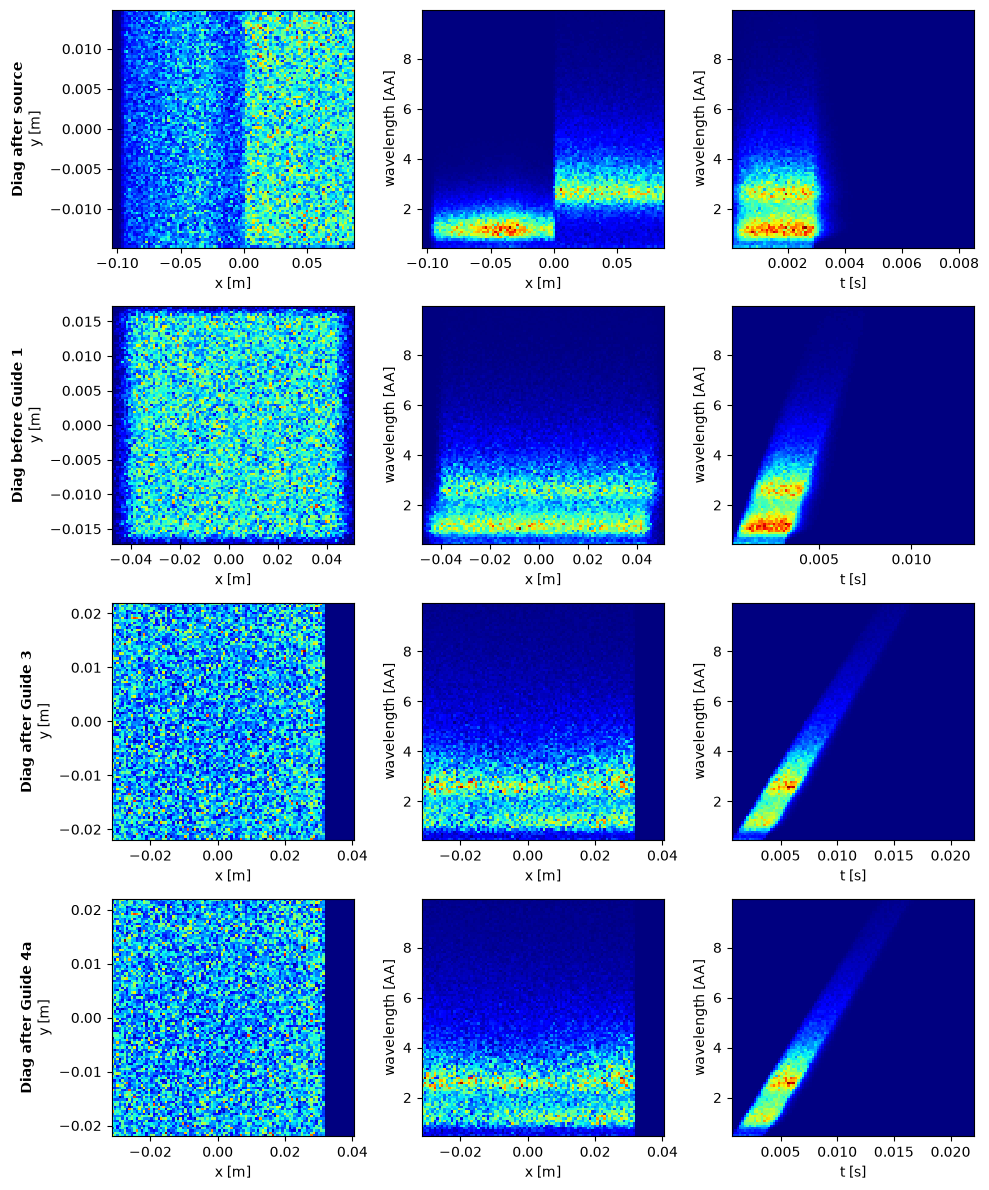

In [38]:
# %matplotlib widget
%matplotlib inline
diag.plot()

int    bender  = 0          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


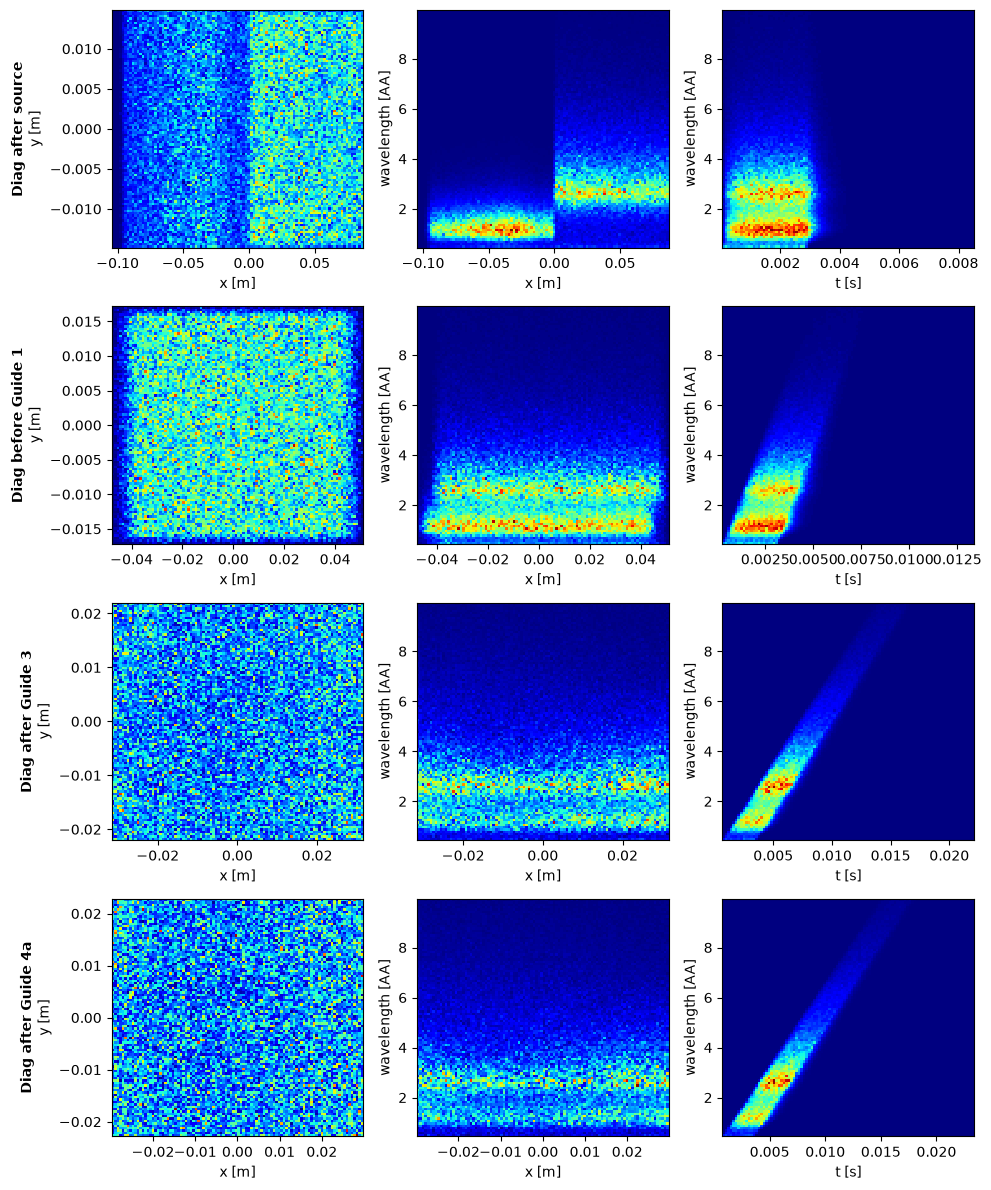

In [39]:
diag.set_parameters(bender=0)
diag.show_parameters()
diag.run()
diag.plot()